In [10]:
import pickle
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from transformers import BertModel, BertTokenizer
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import gc

In [11]:
import os

In [12]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BASE_PATH = '/content/drive/MyDrive/embeddings_assignment/processed_data/'
tokenizer_bert = BertTokenizer.from_pretrained('bert-base-uncased')

In [13]:
OUTPUT_PATH = '/content/drive/MyDrive/embeddings_assignment/bert_pipeline_results/'
os.makedirs(OUTPUT_PATH, exist_ok=True)

In [14]:
class BERTContextDataset(Dataset):
    def __init__(self, data):
        self.sentences = data['tokens']
        self.tags = data['tags']
    def __len__(self): return len(self.sentences)
    def __getitem__(self, idx):
        text_string = " ".join(self.sentences[idx])
        encoding = tokenizer_bert(text_string, truncation=True, max_length=512, return_tensors=None)
        input_ids = encoding['input_ids']
        labels = self.tags[idx][:len(input_ids)]
        labels += [-100] * (len(input_ids) - len(labels))
        return torch.tensor(input_ids), torch.tensor(labels)

In [15]:
def collate_fn(batch):
    ids, tags = zip(*batch)
    padded_ids = pad_sequence(ids, batch_first=True, padding_value=tokenizer_bert.pad_token_id)
    padded_tags = pad_sequence(tags, batch_first=True, padding_value=-100)
    attention_masks = (padded_ids != tokenizer_bert.pad_token_id).long()
    return padded_ids, attention_masks, padded_tags

In [16]:
class BertBiLSTMNER(nn.Module):
    def __init__(self, hidden_dim, target_size):
        super().__init__()
        self.bert = BertModel.from_pretrained('bert-base-uncased')
        for param in self.bert.parameters():
            param.requires_grad = False
        self.lstm = nn.LSTM(768, hidden_dim // 2, bidirectional=True, batch_first=True)
        self.fc = nn.Linear(hidden_dim, target_size)

    def forward(self, ids, mask):
        with torch.no_grad():
            bert_outputs = self.bert(input_ids=ids, attention_mask=mask)
        return self.fc(self.lstm(bert_outputs.last_hidden_state)[0])

In [17]:
tokenizers = ['whitespace', 'nltk', 'wordpiece']
TAG_LABELS = ['O', 'B-Disease', 'I-Disease']


================ RUNNING: BERT + WHITESPACE ================


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


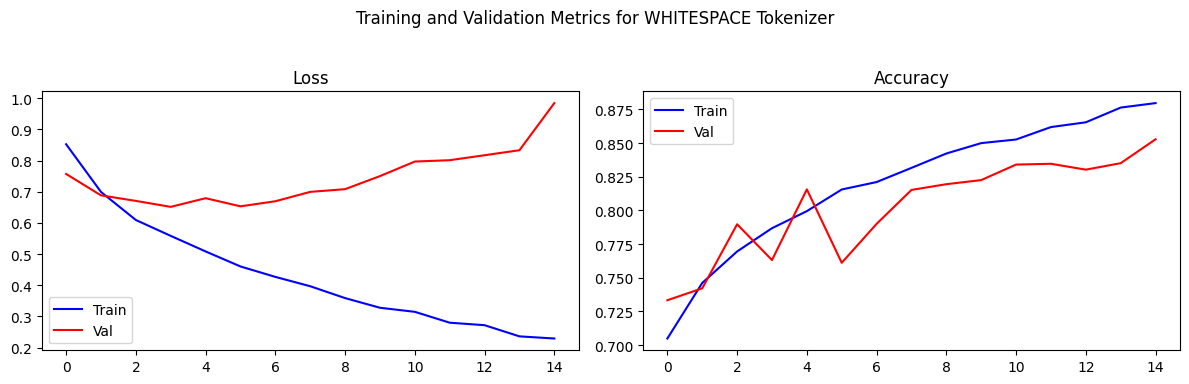

              precision    recall  f1-score   support

           O       0.98      0.87      0.92    117589
   B-Disease       0.18      0.63      0.28      4424
   I-Disease       0.24      0.47      0.32      2737

    accuracy                           0.85    124750
   macro avg       0.47      0.66      0.51    124750
weighted avg       0.94      0.85      0.89    124750



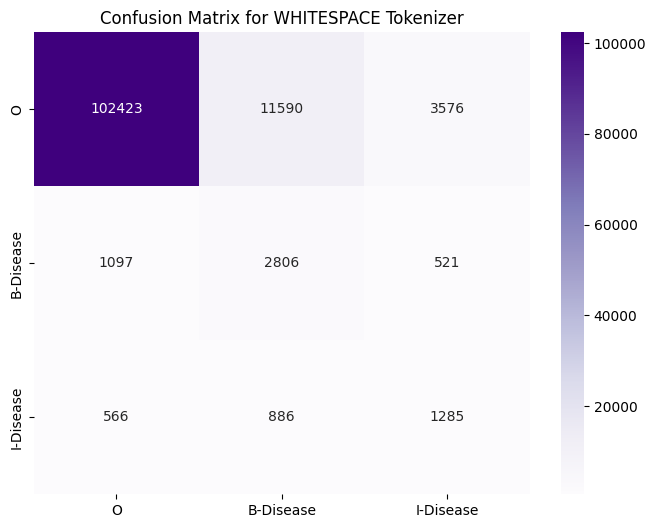


================ RUNNING: BERT + NLTK ================


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


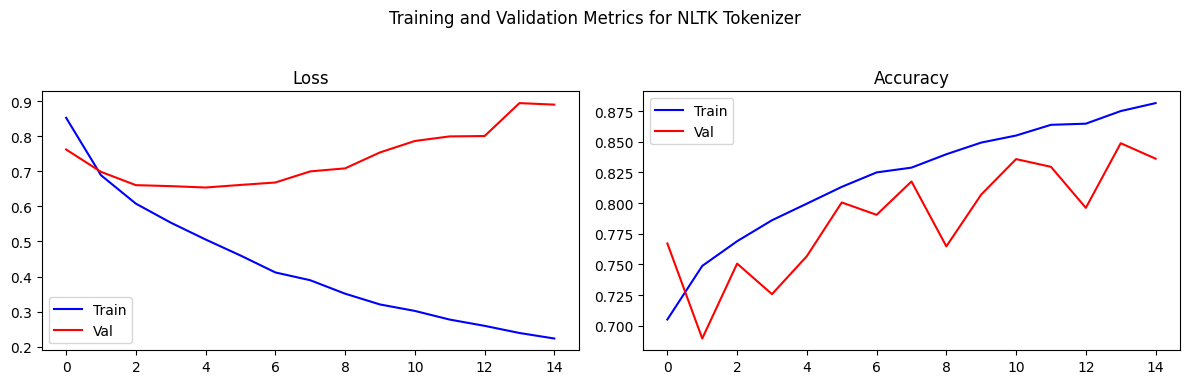

              precision    recall  f1-score   support

           O       0.99      0.85      0.91    117595
   B-Disease       0.18      0.60      0.28      4424
   I-Disease       0.20      0.63      0.31      2737

    accuracy                           0.84    124756
   macro avg       0.46      0.70      0.50    124756
weighted avg       0.94      0.84      0.88    124756



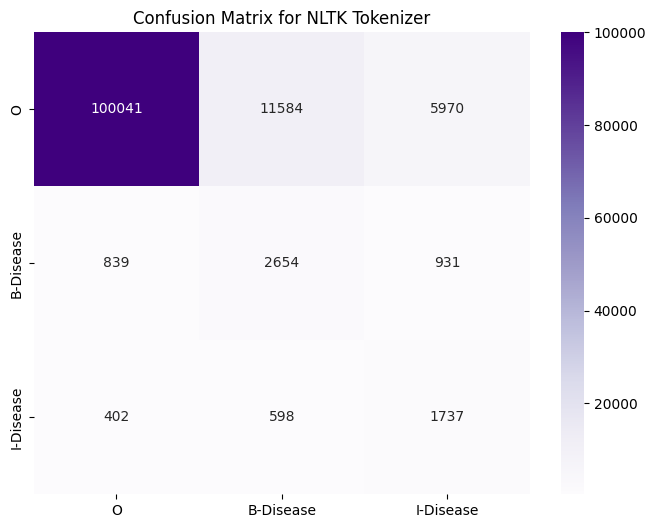


================ RUNNING: BERT + WORDPIECE ================


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


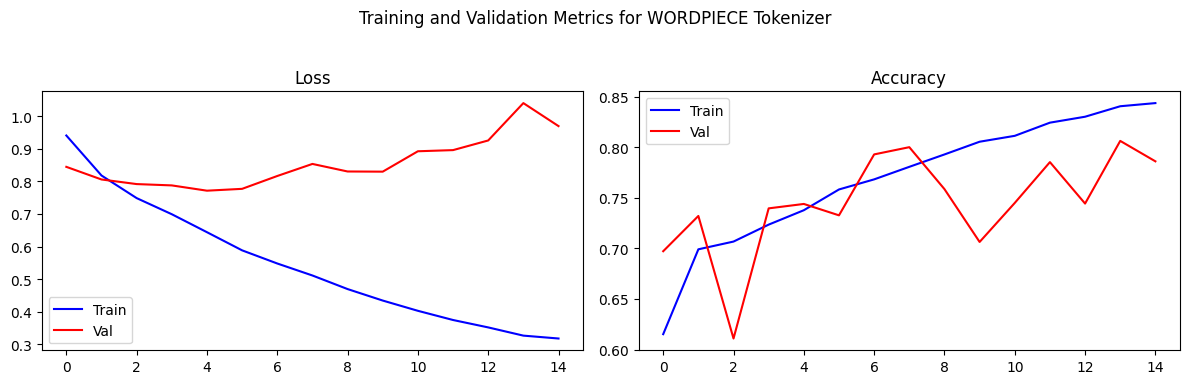

              precision    recall  f1-score   support

           O       0.98      0.80      0.88    117589
   B-Disease       0.13      0.56      0.22      4424
   I-Disease       0.13      0.53      0.21      2737

    accuracy                           0.78    124750
   macro avg       0.42      0.63      0.44    124750
weighted avg       0.94      0.78      0.84    124750



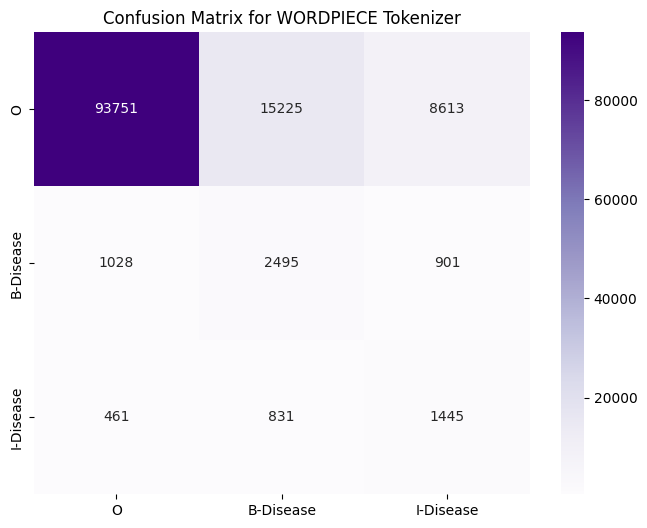

In [19]:
for tok in tokenizers:
    print(f"\n================ RUNNING: BERT + {tok.upper()} ================")
    with open(f'{BASE_PATH}train_{tok}.pkl', 'rb') as f: train_pkl = pickle.load(f)
    with open(f'{BASE_PATH}val_{tok}.pkl', 'rb') as f: val_pkl = pickle.load(f)
    with open(f'{BASE_PATH}test_{tok}.pkl', 'rb') as f: test_pkl = pickle.load(f)

    train_loader = DataLoader(BERTContextDataset(train_pkl), batch_size=16, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(BERTContextDataset(val_pkl), batch_size=16, shuffle=False, collate_fn=collate_fn)
    test_loader = DataLoader(BERTContextDataset(test_pkl), batch_size=16, shuffle=False, collate_fn=collate_fn)

    # Calculate Weights
    flat_tags = [t for tags in train_pkl['tags'] for t in tags if t != -100]
    class_counts = np.bincount(flat_tags, minlength=len(TAG_LABELS))
    class_counts = np.where(class_counts == 0, 1, class_counts)
    class_weights = sum(class_counts) / (len(TAG_LABELS) * class_counts)
    class_weights_tensor = torch.FloatTensor(class_weights).to(device)

    model = BertBiLSTMNER(128, len(TAG_LABELS)).to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, ignore_index=-100)

    t_loss, v_loss, t_acc, v_acc = [], [], [], []
    for epoch in range(15):
        model.train()
        loss_val, ok, tot = 0, 0, 0
        for ids, mask, tags in train_loader:
            ids, mask, tags = ids.to(device), mask.to(device), tags.to(device)
            optimizer.zero_grad()
            out = model(ids, mask)
            loss = criterion(out.view(-1, out.shape[-1]), tags.view(-1))
            loss.backward()
            optimizer.step()
            loss_val += loss.item()

            preds = torch.argmax(out, dim=-1)
            active_mask = tags != -100
            ok += (preds[active_mask] == tags[active_mask]).sum().item()
            tot += active_mask.sum().item()

        model.eval()
        v_loss_val, v_ok, v_tot = 0, 0, 0
        with torch.no_grad():
            for ids, mask, tags in val_loader:
                ids, mask, tags = ids.to(device), mask.to(device), tags.to(device)
                out = model(ids, mask)
                loss = criterion(out.view(-1, out.shape[-1]), tags.view(-1))
                v_loss_val += loss.item()
                preds = torch.argmax(out, dim=-1)
                active_mask = tags != -100
                v_ok += (preds[active_mask] == tags[active_mask]).sum().item()
                v_tot += active_mask.sum().item()

        t_loss.append(loss_val/len(train_loader)); t_acc.append(ok/max(1,tot))
        v_loss.append(v_loss_val/len(val_loader)); v_acc.append(v_ok/max(1,v_tot))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(t_loss, 'b-', label='Train'); ax1.plot(v_loss, 'r-', label='Val'); ax1.set_title('Loss'); ax1.legend()
    ax2.plot(t_acc, 'b-', label='Train'); ax2.plot(v_acc, 'r-', label='Val'); ax2.set_title('Accuracy'); ax2.legend()
    plt.suptitle(f'Training and Validation Metrics for {tok.upper()} Tokenizer')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(OUTPUT_PATH, f'loss_acc_plot_{tok}.png'))
    plt.show()

    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
        for ids, mask, tags in test_loader:
            ids, mask = ids.to(device), mask.to(device)
            preds = torch.argmax(model(ids, mask), dim=-1).cpu()
            active_mask = tags != -100
            y_true.extend(tags[active_mask].tolist()); y_pred.extend(preds[active_mask].tolist())

    report = classification_report(y_true, y_pred, target_names=TAG_LABELS, labels=range(len(TAG_LABELS)), zero_division=0)
    print(report)
    with open(os.path.join(OUTPUT_PATH, f'classification_report_{tok}.txt'), 'w') as f:
        f.write(report)

    plt.figure(figsize=(8, 6))
    sns.heatmap(confusion_matrix(y_true, y_pred, labels=range(len(TAG_LABELS))), annot=True, fmt='d', cmap='Purples', xticklabels=TAG_LABELS, yticklabels=TAG_LABELS)
    plt.title(f'Confusion Matrix for {tok.upper()} Tokenizer')
    plt.savefig(os.path.join(OUTPUT_PATH, f'confusion_matrix_{tok}.png'))
    plt.show()
    plt.close('all')

    del model, train_loader, val_loader, test_loader
    gc.collect(); torch.cuda.empty_cache()